In [ ]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Helper function for visualization
def visualize_samples(images, masks, titles, num_samples=3):
    """Utility to visualize image-mask pairs."""
    fig, axes = plt.subplots(num_samples, 2, figsize=(6, 2 * num_samples))
    if num_samples == 1:
        axes = np.array([axes])

    indices = np.random.choice(len(images), num_samples, replace=False)

    for i, idx in enumerate(indices):
        axes[i, 0].imshow(images[idx], cmap='gray')
        axes[i, 0].set_title(titles[0])
        axes[i, 0].axis('off')

        axes[i, 1].imshow(masks[idx], cmap='gray')
        axes[i, 1].set_title(titles[1])
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
# Load MNIST data from Keras
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Combine train and test sets to get a 70,000 image pool
base_images = np.concatenate((x_train, x_test), axis=0)
base_labels = np.concatenate((y_train, y_test), axis=0)

num_total_samples = len(base_images)
print(f"Loaded {num_total_samples} base MNIST images and labels.")

Loaded 70000 base MNIST images and labels.


# Q1A)

Creating Dataset (a): Foreground Segmentation Masks...
Dataset (a) created. Mask shape: (70000, 28, 28)


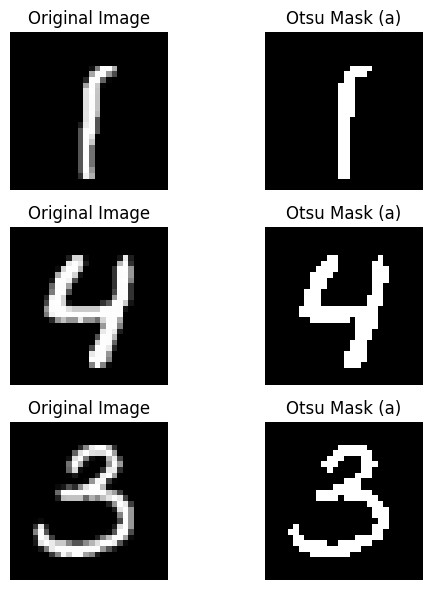

In [ ]:
def create_otsu_masks(images):

    masks = []
    for img in images:

        # We get a mask of 0s and 255s.
        _, binary_mask = cv2.threshold(
            img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
        )
        # Convert mask to 0 (background) and 1 (foreground)
        binary_mask[binary_mask == 255] = 1
        masks.append(binary_mask)
    return np.array(masks, dtype=np.uint8)

print("Creating Dataset (a): Foreground Segmentation Masks...")
dataset_a_masks = create_otsu_masks(base_images)

# Images: base_images
# Masks: dataset_a_masks

print(f"Dataset (a) created. Mask shape: {dataset_a_masks.shape}")

# Visualize a few samples from Dataset (a)
visualize_samples(base_images, dataset_a_masks,
                  titles=["Original Image", "Otsu Mask (a)"],
                  num_samples=3)

In [ ]:
# --- Configuration for saving 1(a) ---
import tensorflow as tf
import cv2
import numpy as np
import h5py
import math
from tqdm import tqdm
TOTAL_IMAGES_TO_SAVE = num_total_samples  # 70,000
BATCH_SIZE = 128
FILENAME_A = 'dataset_a_foreground.h5'
num_batches = math.ceil(TOTAL_IMAGES_TO_SAVE / BATCH_SIZE)
img_h, img_w = base_images.shape[1:]
print(f"\nPreparing to save {TOTAL_IMAGES_TO_SAVE} samples to '{FILENAME_A}'...")

with h5py.File(FILENAME_A, 'w') as f:
    # Create datasets for images and masks
    dset_images = f.create_dataset(
        'images',
        shape=(TOTAL_IMAGES_TO_SAVE, img_h, img_w),
        dtype='uint8',
        chunks=(BATCH_SIZE, img_h, img_w),
        compression="gzip"
    )
    dset_masks = f.create_dataset(
        'masks',
        shape=(TOTAL_IMAGES_TO_SAVE, img_h, img_w),
        dtype='uint8',
        chunks=(BATCH_SIZE, img_h, img_w),
        compression="gzip"
    )

    current_index = 0
    for i in tqdm(range(num_batches), desc=f"Saving {FILENAME_A}"):
        start_idx = current_index
        end_idx = min(current_index + BATCH_SIZE, TOTAL_IMAGES_TO_SAVE)

        # Get slices from our pre-generated arrays
        batch_images_slice = base_images[start_idx:end_idx]
        batch_masks_slice = dataset_a_masks[start_idx:end_idx]

        # Write the slices to the file
        dset_images[start_idx:end_idx] = batch_images_slice
        dset_masks[start_idx:end_idx] = batch_masks_slice

        current_index = end_idx

print(f"✅ Successfully saved {current_index} images and masks to '{FILENAME_A}'.")


Preparing to save 70000 samples to 'dataset_a_foreground.h5'...


Saving dataset_a_foreground.h5: 100%|██████████| 547/547 [00:01<00:00, 277.39it/s]

✅ Successfully saved 70000 images and masks to 'dataset_a_foreground.h5'.


# Q1B)


Creating Dataset (b): Circular Localization Masks...
Dataset (b) created. Mask shape: (70000, 28, 28)


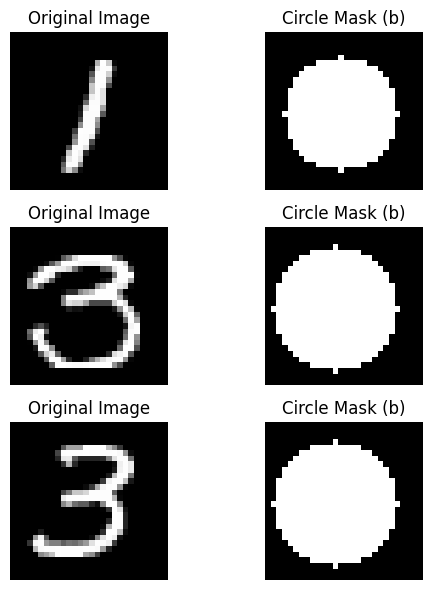

In [ ]:
def create_circle_masks(binary_masks):

    circle_masks = []
    for mask in binary_masks:
        # Find contours of the digit

        contours, _ = cv2.findContours(
            mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )

        # Create a blank mask to draw the circle on
        circle_mask = np.zeros_like(mask, dtype=np.uint8)

        if contours:
            # Combine all contour points (in case of fragmented digits)
            all_points = np.concatenate(contours, axis=0)

            if len(all_points) > 0:
                # Find the minimum enclosing circle
                (x, y), radius = cv2.minEnclosingCircle(all_points)


                cv2.circle(
                    circle_mask,
                    center=(int(x), int(y)),
                    radius=int(radius),
                    color=1,
                    thickness=-1
                )

        circle_masks.append(circle_mask)
    return np.array(circle_masks, dtype=np.uint8)

print("\nCreating Dataset (b): Circular Localization Masks...")

dataset_b_masks = create_circle_masks(dataset_a_masks)



print(f"Dataset (b) created. Mask shape: {dataset_b_masks.shape}")

visualize_samples(base_images, dataset_b_masks,
                  titles=["Original Image", "Circle Mask (b)"],
                  num_samples=3)

In [ ]:

TOTAL_IMAGES_TO_SAVE = num_total_samples
BATCH_SIZE = 128
FILENAME_B = 'dataset_b_circlization.h5'
num_batches = math.ceil(TOTAL_IMAGES_TO_SAVE / BATCH_SIZE)
img_h, img_w = base_images.shape[1:]

print(f"\nPreparing to save {TOTAL_IMAGES_TO_SAVE} samples to '{FILENAME_B}'...")

with h5py.File(FILENAME_B, 'w') as f:

    dset_images = f.create_dataset(
        'images',
        shape=(TOTAL_IMAGES_TO_SAVE, img_h, img_w),
        dtype='uint8',
        chunks=(BATCH_SIZE, img_h, img_w),
        compression="gzip"
    )
    dset_masks = f.create_dataset(
        'masks',
        shape=(TOTAL_IMAGES_TO_SAVE, img_h, img_w),
        dtype='uint8',
        chunks=(BATCH_SIZE, img_h, img_w),
        compression="gzip"
    )
    dset_labels = f.create_dataset(
        'labels',
        shape=(TOTAL_IMAGES_TO_SAVE,),
        dtype='uint8',
        chunks=(BATCH_SIZE,),
        compression="gzip"
    )

    current_index = 0
    for i in tqdm(range(num_batches), desc=f"Saving {FILENAME_B}"):
        start_idx = current_index
        end_idx = min(current_index + BATCH_SIZE, TOTAL_IMAGES_TO_SAVE)

        batch_images_slice = base_images[start_idx:end_idx]
        batch_masks_slice = dataset_b_masks[start_idx:end_idx]
        batch_labels_slice = base_labels[start_idx:end_idx]

        dset_images[start_idx:end_idx] = batch_images_slice
        dset_masks[start_idx:end_idx] = batch_masks_slice
        dset_labels[start_idx:end_idx] = batch_labels_slice

        current_index = end_idx

print(f"✅ Successfully saved {current_index} images, masks, and labels to '{FILENAME_B}'.")


Preparing to save 70000 samples to 'dataset_b_circlization.h5'...


Saving dataset_b_circlization.h5: 100%|██████████| 547/547 [00:03<00:00, 146.80it/s]

✅ Successfully saved 70000 images, masks, and labels to 'dataset_b_circlization.h5'.


# Q1C)


Creating Dataset (c): 2x2 Semantic Segmentation Generator...
Dataset (c) generator created.
Sample image batch shape: (32, 56, 56)
Sample mask batch shape: (32, 56, 56)
Unique classes in sample mask (c): [0 1 2]


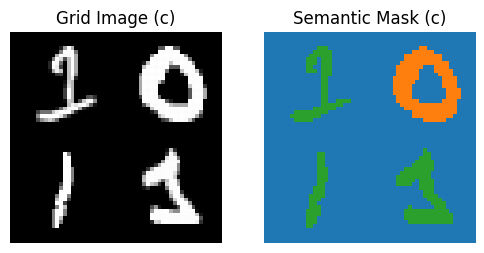

In [ ]:
def generate_2x2_grid_batch(batch_size=32):

    global base_images, dataset_a_masks, base_labels, num_total_samples

    img_h, img_w = base_images[0].shape
    grid_h, grid_w = img_h * 2, img_w * 2

    while True:
        batch_images = np.zeros((batch_size, grid_h, grid_w), dtype=np.uint8)
        batch_masks = np.zeros((batch_size, grid_h, grid_w), dtype=np.uint8)

        for i in range(batch_size):
            idx1, idx2, idx3, idx4 = np.random.randint(0, num_total_samples, 4)

            imgs = [
                base_images[idx1], base_images[idx2],
                base_images[idx3], base_images[idx4]
            ]
            masks_a = [
                dataset_a_masks[idx1], dataset_a_masks[idx2],
                dataset_a_masks[idx3], dataset_a_masks[idx4]
            ]
            labels = [
                base_labels[idx1], base_labels[idx2],
                base_labels[idx3], base_labels[idx4]
            ]

            top_row_img = np.hstack((imgs[0], imgs[1]))
            bottom_row_img = np.hstack((imgs[2], imgs[3]))
            batch_images[i] = np.vstack((top_row_img, bottom_row_img))

            sem_mask1 = masks_a[0] * (labels[0] + 1)
            sem_mask2 = masks_a[1] * (labels[1] + 1)
            sem_mask3 = masks_a[2] * (labels[2] + 1)
            sem_mask4 = masks_a[3] * (labels[3] + 1)

            top_row_mask = np.hstack((sem_mask1, sem_mask2))
            bottom_row_mask = np.hstack((sem_mask3, sem_mask4))
            batch_masks[i] = np.vstack((top_row_mask, bottom_row_mask))

        yield batch_images, batch_masks.astype(np.uint8)

print("\nCreating Dataset (c): 2x2 Semantic Segmentation Generator...")

dataset_c_generator = generate_2x2_grid_batch(batch_size=32)

sample_c_images, sample_c_masks = next(dataset_c_generator)

print("Dataset (c) generator created.")
print(f"Sample image batch shape: {sample_c_images.shape}")
print(f"Sample mask batch shape: {sample_c_masks.shape}")

img_c = sample_c_images[0]
mask_c = sample_c_masks[0]
print(f"Unique classes in sample mask (c): {np.unique(mask_c)}")

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(img_c, cmap='gray')
axes[0].set_title("Grid Image (c)")
axes[0].axis('off')

axes[1].imshow(mask_c, cmap='tab20', vmin=0, vmax=10)
axes[1].set_title("Semantic Mask (c)")
axes[1].axis('off')
plt.show()

In [ ]:
import h5py
import numpy as np
from tqdm import tqdm
import math



TOTAL_IMAGES_TO_SAVE = 250000
BATCH_SIZE = 128
FILENAME = 'dataset_c_semantic_grid.h5'

num_batches = math.ceil(TOTAL_IMAGES_TO_SAVE / BATCH_SIZE)

temp_gen = generate_2x2_grid_batch(batch_size=2)
temp_imgs, temp_masks = next(temp_gen)
img_h, img_w = temp_imgs.shape[1:]
mask_h, mask_w = temp_masks.shape[1:]
del temp_gen, temp_imgs, temp_masks

dataset_c_generator = generate_2x2_grid_batch(batch_size=BATCH_SIZE)

print(f"Preparing to save {TOTAL_IMAGES_TO_SAVE} samples to '{FILENAME}'...")

with h5py.File(FILENAME, 'w') as f:

    dset_images = f.create_dataset(
        'images',
        shape=(TOTAL_IMAGES_TO_SAVE, img_h, img_w),
        dtype='uint8',
        chunks=(BATCH_SIZE, img_h, img_w),
        compression="gzip"
    )

    dset_masks = f.create_dataset(
        'masks',
        shape=(TOTAL_IMAGES_TO_SAVE, mask_h, mask_w),
        dtype='uint8',
        chunks=(BATCH_SIZE, mask_h, mask_w),
        compression="gzip"
    )

    current_index = 0

    for i in tqdm(range(num_batches), desc="Generating & Saving Batches"):
        if i == num_batches - 1:
            num_remaining = TOTAL_IMAGES_TO_SAVE - current_index
            if num_remaining <= 0:
                break
            final_generator = generate_2x2_grid_batch(batch_size=num_remaining)
            batch_images, batch_masks = next(final_generator)
        else:

            batch_images, batch_masks = next(dataset_c_generator)

        start_idx = current_index
        end_idx = start_idx + len(batch_images)

        dset_images[start_idx:end_idx] = batch_images
        dset_masks[start_idx:end_idx] = batch_masks

        current_index = end_idx

print(f"\n✅ Successfully saved {current_index} images and masks to '{FILENAME}'.")

Preparing to save 250000 samples to 'dataset_c_semantic_grid.h5'...


Generating & Saving Batches: 100%|██████████| 1954/1954 [00:45<00:00, 42.73it/s]


✅ Successfully saved 250000 images and masks to 'dataset_c_semantic_grid.h5'.


# Q2)

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Conv2DTranspose,
    concatenate, Dropout, BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
import numpy as np
import h5py
import matplotlib.pyplot as plt

print(f"TensorFlow Version: {tf.__version__}")

# --- 1(a). Load Data from HDF5 File ---
FILENAME_A = 'dataset_a_foreground.h5'
print(f"Loading data from {FILENAME_A}...")

with h5py.File(FILENAME_A, 'r') as f:
    # Load all 70,000 samples
    all_images = f['images'][:]
    all_masks = f['masks'][:]

print("Data loaded. Re-creating 60k/10k train/test split...")

# Shuffle indices to create a random 60k/10k split
indices = np.arange(len(all_images))
np.random.shuffle(indices)

# Assign 10,000 to test, 60,000 to train
test_indices = indices[:10000]
train_indices = indices[10000:]


x_train = all_images[train_indices]
y_train_masks = all_masks[train_indices]

x_test = all_images[test_indices]
y_test_masks = all_masks[test_indices]

print(f"Original x_train shape: {x_train.shape}")
print(f"Created y_train_masks shape: {y_train_masks.shape}")

# --- 1(b). Preprocess the Data (as in your code) ---
# Normalize images to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Add channel dimension (for Conv2D)
IMG_HEIGHT, IMG_WIDTH = 28, 28
x_train = np.expand_dims(x_train, axis=-1)
y_train_masks = np.expand_dims(y_train_masks, axis=-1).astype('float32') # Cast for training

x_test = np.expand_dims(x_test, axis=-1)
y_test_masks = np.expand_dims(y_test_masks, axis=-1).astype('float32') # Cast for training

print(f"Processed x_train shape: {x_train.shape}")
print(f"Processed y_train_masks shape: {y_train_masks.shape}")

# --- 1(c). Create 10k Subset (your exact code) ---
SUBSET_SIZE = 10000
indices = np.arange(x_train.shape[0])
np.random.shuffle(indices)

# Select the first 10k indices
train_indices_subset = indices[:SUBSET_SIZE]

# Create the new 10k subsets by slicing the full arrays
x_train_subset = x_train[train_indices_subset]
y_train_masks_subset = y_train_masks[train_indices_subset]

print("\n--- 10k Subset Created ---")
print(f"x_train_subset shape: {x_train_subset.shape}")
print(f"y_train_masks_subset shape: {y_train_masks_subset.shape}")
print(f"x_test (unchanged) shape: {x_test.shape}")
print(f"y_test_masks (unchanged) shape: {y_test_masks.shape}")

TensorFlow Version: 2.19.0
Loading data from dataset_a_foreground.h5...
Data loaded. Re-creating 60k/10k train/test split...
Original x_train shape: (60000, 28, 28)
Created y_train_masks shape: (60000, 28, 28)
Processed x_train shape: (60000, 28, 28, 1)
Processed y_train_masks shape: (60000, 28, 28, 1)

--- 10k Subset Created ---
x_train_subset shape: (10000, 28, 28, 1)
y_train_masks_subset shape: (10000, 28, 28, 1)
x_test (unchanged) shape: (10000, 28, 28, 1)
y_test_masks (unchanged) shape: (10000, 28, 28, 1)


In [ ]:
def build_mini_unet(input_shape=(IMG_HEIGHT, IMG_WIDTH, 1)):


    inputs = Input(input_shape)

    # --- Encoder (Contracting Path) ---
    # Block 1
    c1 = Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
    c1 = Conv2D(16, (3, 3), activation='relu', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1) # 14x14

    # Block 2
    c2 = Conv2D(32, (3, 3), activation='relu', padding='same')(p1)
    c2 = Conv2D(32, (3, 3), activation='relu', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2) # 7x7

    # --- Bottleneck ---
    c3 = Conv2D(64, (3, 3), activation='relu', padding='same')(p2)
    c3 = Conv2D(64, (3, 3), activation='relu', padding='same')(c3)

    # --- Decoder (Expanding Path) ---
    # Block 2'
    u2 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c3) # 14x14
    u2 = concatenate([u2, c2]) # Skip connection
    c4 = Conv2D(32, (3, 3), activation='relu', padding='same')(u2)
    c4 = Conv2D(32, (3, 3), activation='relu', padding='same')(c4)

    # Block 1'
    u1 = Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c4) # 28x28
    u1 = concatenate([u1, c1]) # Skip connection
    c5 = Conv2D(16, (3, 3), activation='relu', padding='same')(u1)
    c5 = Conv2D(16, (3, 3), activation='relu', padding='same')(c5)

    # --- Output Layer ---

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c5)

    model = Model(inputs=[inputs], outputs=[outputs])
    return model

# Build the model
model = build_mini_unet()
model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_116 (Conv2D) │ (None, 28, 28,    │        160 │ input_layer_9[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_117 (Conv2D) │ (None, 28, 28,    │      2,320 │ conv2d_116[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_23    │ (None, 14, 14,    │          0 │ conv2d_117[0][0]  │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_118 (Conv2D) │ (None, 14, 14,    │      4,640 │ max_pooling2d_23… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_119 (Conv2D) │ (None, 14, 14,    │      9,248 │ conv2d_118[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_24    │ (None, 7, 7, 32)  │          0 │ conv2d_119[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_120 (Conv2D) │ (None, 7, 7, 64)  │     18,496 │ max_pooling2d_24… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_121 (Conv2D) │ (None, 7, 7, 64)  │     36,928 │ conv2d_120[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_23 │ (None, 14, 14,    │      8,224 │ conv2d_121[0][0]  │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_23      │ (None, 14, 14,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 64)               │            │ conv2d_119[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_122 (Conv2D) │ (None, 14, 14,    │     18,464 │ concatenate_23[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_123 (Conv2D) │ (None, 14, 14,    │      9,248 │ conv2d_122[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_24 │ (None, 28, 28,    │      2,064 │ conv2d_123[0][0]  │
│ (Conv2DTranspose)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_24      │ (None, 28, 28,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 32)               │            │ conv2d_117[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_124 (Conv2D) │ (None, 28, 28,    │      4,624 │ concatenate_24[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_125 (Conv2D) │ (None, 28, 28,    │      2,320 │ conv2d_124[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 116,753 (456.07 KB)

 Trainable params: 116,753 (456.07 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def iou_metric(y_true, y_pred, smooth=1e-6):

    # Threshold predicted probabilities
    y_pred_binary = K.round(y_pred)

    # Cast to float for division
    y_true_f = K.cast(y_true, 'float32')
    y_pred_f = K.cast(y_pred_binary, 'float32')

    # Calculate intersection and union
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection

    # Calculate IoU
    iou = (intersection + smooth) / (union + smooth)
    return iou

In [ ]:
model = build_mini_unet()

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[iou_metric]
)


history = model.fit(
    x_train_subset,
    y_train_masks_subset,
    batch_size=32,
    epochs=5,
    validation_data=(x_test, y_test_masks)
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 88s 259ms/step - iou_metric: 0.6479 - loss: 0.1726 - val_iou_metric: 0.9623 - val_loss: 0.0131
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 78s 246ms/step - iou_metric: 0.9659 - loss: 0.0117 - val_iou_metric: 0.9715 - val_loss: 0.0089
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 75s 241ms/step - iou_metric: 0.9815 - loss: 0.0064 - val_iou_metric: 0.9897 - val_loss: 0.0040
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 76s 243ms/step - iou_metric: 0.9894 - loss: 0.0039 - val_iou_metric: 0.9918 - val_loss: 0.0032
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 78s 250ms/step - iou_metric: 0.9911 - loss: 0.0032 - val_iou_metric: 0.9929 - val_loss: 0.0027


In [ ]:
print("\n--- Evaluating on Test Set ---")
# Assumes your model is 'model' and test data is 'x_test', 'y_test_masks'
results = model.evaluate(x_test, y_test_masks, batch_size=32)

print("\n" + "="*30)
print("  FINAL TEST PERFORMANCE REPORT (Q2)")
print("="*30)
# results[0] is the loss, results[1] is the first metric (our IoU)
print(f"Test Loss (binary_crossentropy): {results[0]:.4f}")
print(f"Test IoU: {results[1]:.4f}")
print("="*30)


--- Evaluating on Test Set ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - iou_metric: 0.9926 - loss: 0.0027

  FINAL TEST PERFORMANCE REPORT (Q2)
Test Loss (binary_crossentropy): 0.0027
Test IoU: 0.9929


Running model.predict() on the test set...
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step
Plotting 5 random test samples...


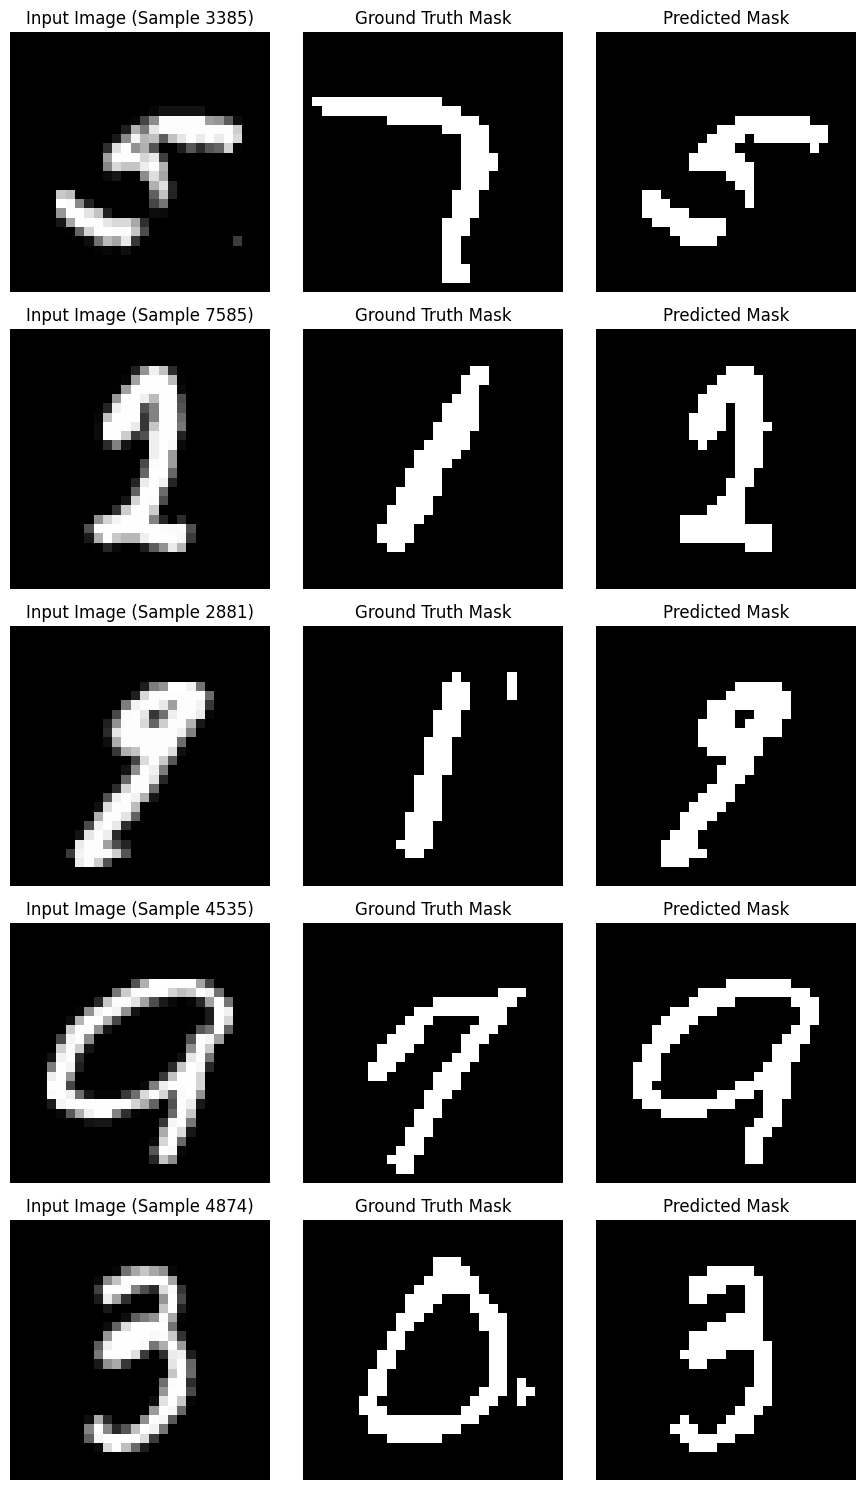

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Get Model Predictions ---
print("Running model.predict() on the test set...")

pred_masks_prob = model.predict(x_test)

# Convert probabilities (0.0 - 1.0) to binary masks (0 or 1)
pred_masks_binary = np.round(pred_masks_prob)

# --- 2. Select 5 Random Samples ---
num_to_show = 5
indices = np.random.choice(len(x_test), num_to_show, replace=False)

# --- 3. Plot the Results ---
print(f"Plotting {num_to_show} random test samples...")
fig, axes = plt.subplots(num_to_show, 3, figsize=(9, num_to_show * 3))

for i, idx in enumerate(indices):
    img = np.squeeze(x_test[idx])
    true_mask = np.squeeze(y_test_masks[idx])
    pred_mask = np.squeeze(pred_masks_binary[idx])

    # --- Plot Input Image ---
    axes[i, 0].imshow(img, cmap='gray')
    axes[i, 0].set_title(f"Input Image (Sample {idx})")
    axes[i, 0].axis('off')

    # --- Plot Ground Truth ---
    axes[i, 1].imshow(true_mask, cmap='gray')
    axes[i, 1].set_title("Ground Truth Mask")
    axes[i, 1].axis('off')

    # --- Plot Predicted Mask ---
    axes[i, 2].imshow(pred_mask, cmap='gray')
    axes[i, 2].set_title("Predicted Mask")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

# Q3)

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Conv2DTranspose,
    concatenate, Flatten, Dense
)
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
import numpy as np
import h5py
import matplotlib.pyplot as plt

print(f"TensorFlow Version: {tf.__version__}")

# --- 1(a). Load Data from HDF5 File ---
FILENAME_B = 'dataset_b_circlization.h5'
print(f"Loading data from {FILENAME_B}...")

with h5py.File(FILENAME_B, 'r') as f:
    # Load all 70,000 samples
    all_images = f['images'][:]
    all_masks = f['masks'][:]
    all_labels = f['labels'][:]

print("Data loaded. Re-creating 60k/10k train/test split...")

# Shuffle indices to create a random 60k/10k split
indices = np.arange(len(all_images))
np.random.shuffle(indices)

# Assign 10,000 to test, 60,000 to train
test_indices = indices[:10000]
train_indices = indices[10000:]


x_train = all_images[train_indices]
y_train_class = all_labels[train_indices]
y_train_mask = all_masks[train_indices] # The circle masks

x_test = all_images[test_indices]
y_test_class = all_labels[test_indices]
y_test_mask = all_masks[test_indices] # The circle masks

# --- 2. Preprocess Data  ---
IMG_HEIGHT, IMG_WIDTH = 28, 28

x_train = (x_train.astype('float32') / 255.0).reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1)
x_test = (x_test.astype('float32') / 255.0).reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1)

# Reshape masks (Y_mask)
y_train_mask = y_train_mask.reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1).astype('float32')
y_test_mask = y_test_mask.reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1).astype('float32')

print(f"x_train shape: {x_train.shape}")
print(f"y_train_class shape: {y_train_class.shape}")
print(f"y_train_mask shape: {y_train_mask.shape}")

# --- 3. Create 10k Subset (Your exact code) ---
SUBSET_SIZE = 10000

indices = np.arange(x_train.shape[0])
np.random.shuffle(indices)

train_indices = indices[:SUBSET_SIZE]

# Create the new subset
x_train_subset = x_train[train_indices]
y_train_class_subset = y_train_class[train_indices]
y_train_mask_subset = y_train_mask[train_indices]

print(f"\nUsing subset of {SUBSET_SIZE} images for training.")
print(f"x_train_subset shape: {x_train_subset.shape}")
print(f"y_train_class_subset shape: {y_train_class_subset.shape}")
print(f"y_train_mask_subset shape: {y_train_mask_subset.shape}")

TensorFlow Version: 2.19.0
Loading data from dataset_b_circlization.h5...
Data loaded. Re-creating 60k/10k train/test split...
x_train shape: (60000, 28, 28, 1)
y_train_class shape: (60000,)
y_train_mask shape: (60000, 28, 28, 1)

Using subset of 10000 images for training.
x_train_subset shape: (10000, 28, 28, 1)
y_train_class_subset shape: (10000,)
y_train_mask_subset shape: (10000, 28, 28, 1)


In [ ]:
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Conv2DTranspose,
    concatenate, Dropout, BatchNormalization, Flatten, Dense
)
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
import numpy as np
import cv2
import matplotlib.pyplot as plt
def build_multi_head_model(input_shape=(IMG_HEIGHT, IMG_WIDTH, 1)):

    inputs = Input(input_shape)

    # --- Shared Encoder ---
    # Block 1
    c1 = Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
    c1 = Conv2D(16, (3, 3), activation='relu', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    # Block 2
    c2 = Conv2D(32, (3, 3), activation='relu', padding='same')(p1)
    c2 = Conv2D(32, (3, 3), activation='relu', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    # Bottleneck
    c3 = Conv2D(64, (3, 3), activation='relu', padding='same')(p2)
    c3 = Conv2D(64, (3, 3), activation='relu', padding='same')(c3)

    # --- Head 1: Classification ---
    # Takes features from the bottleneck (c3)
    flat = Flatten()(c3)
    d1 = Dense(64, activation='relu')(flat)
    class_output = Dense(10, activation='softmax', name='class_output')(d1)

    # --- Head 2: Segmentation (Circlization) ---
    # Follows a U-Net-like decoder path
    # Block 2'
    u2 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c3) # 14x14
    u2 = concatenate([u2, c2]) # Skip connection
    c4 = Conv2D(32, (3, 3), activation='relu', padding='same')(u2)

    # Block 1'
    u1 = Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c4) # 28x28
    u1 = concatenate([u1, c1]) # Skip connection
    c5 = Conv2D(16, (3, 3), activation='relu', padding='same')(u1)

    # Output Layer
    mask_output = Conv2D(1, (1, 1), activation='sigmoid', name='mask_output')(c5)

    # --- Create Model ---
    model = Model(
        inputs=inputs,
        outputs=[class_output, mask_output],
        name="circlization_model"
    )
    return model

model = build_multi_head_model()
model.summary()

Model: "circlization_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_14      │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_165 (Conv2D) │ (None, 28, 28,    │        160 │ input_layer_14[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_166 (Conv2D) │ (None, 28, 28,    │      2,320 │ conv2d_165[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_33    │ (None, 14, 14,    │          0 │ conv2d_166[0][0]  │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_167 (Conv2D) │ (None, 14, 14,    │      4,640 │ max_pooling2d_33… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_168 (Conv2D) │ (None, 14, 14,    │      9,248 │ conv2d_167[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_34    │ (None, 7, 7, 32)  │          0 │ conv2d_168[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_169 (Conv2D) │ (None, 7, 7, 64)  │     18,496 │ max_pooling2d_34… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_170 (Conv2D) │ (None, 7, 7, 64)  │     36,928 │ conv2d_169[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_33 │ (None, 14, 14,    │      8,224 │ conv2d_170[0][0]  │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_33      │ (None, 14, 14,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 64)               │            │ conv2d_168[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_171 (Conv2D) │ (None, 14, 14,    │     18,464 │ concatenate_33[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_34 │ (None, 28, 28,    │      2,064 │ conv2d_171[0][0]  │
│ (Conv2DTranspose)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 3136)      │          0 │ conv2d_170[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_34      │ (None, 28, 28,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 32)               │            │ conv2d_166[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │    200,768 │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_172 (Conv2D) │ (None, 28, 28,    │      4,624 │ concatenate_34[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_output        │ (None, 10)        │        650 │ dense_3[0][0]     │
│ (Dense)             │                   │            │                 

 Total params: 306,603 (1.17 MB)

 Trainable params: 306,603 (1.17 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import h5py
import cv2
import zipfile
import numpy as np
from tqdm import tqdm

# --- 1. Configuration ---
# Choose which HDF5 file you want to convert
# H5_FILENAME = 'dataset_b_circlization.h5'
# ZIP_FILENAME = 'dataset_b_circlization.zip'

# Or, for dataset (b):
# H5_FILENAME = 'dataset_b_circlization.h5'
# ZIP_FILENAME = 'dataset_b_circlization.zip'

# Or, for dataset (a):
H5_FILENAME = 'dataset_a_foreground.h5'
ZIP_FILENAME = 'dataset_a_foreground.zip'
# --------------------------

# Check if we have labels (only dataset 'b' has them)
HAS_LABELS = (H5_FILENAME == 'dataset_b_circlization.h5')

print(f"Opening HDF5 file: '{H5_FILENAME}'...")

try:
    with h5py.File(H5_FILENAME, 'r') as f:
        # Get the total number of samples
        num_samples = len(f['images'])
        print(f"Found {num_samples} samples. Starting conversion...")

        # Create and open the new ZIP file
        with zipfile.ZipFile(ZIP_FILENAME, 'w', compression=zipfile.ZIP_DEFLATED) as zf:

            # Iterate through all samples with a progress bar
            for i in tqdm(range(num_samples), desc=f"Writing to {ZIP_FILENAME}"):

                # 1. Read data from HDF5
                image = f['images'][i]
                mask = f['masks'][i]

                # 2. Define filenames inside the ZIP
                # zfill(6) makes "1" -> "000001" for correct sorting
                str_id = str(i).zfill(6)
                img_filename = f"data/images/sample_{str_id}.jpg"
                mask_filename = f"data/masks/sample_{str_id}.png"

                # 3. Encode and write image (as JPEG)
                # .jpg is lossy but fine for the input image
                _, img_bytes = cv2.imencode('.jpg', image)
                zf.writestr(img_filename, img_bytes)

                # 4. Encode and write mask (MUST BE PNG)
                # .png is lossless and preserves the mask's 0-10 labels
                _, mask_bytes = cv2.imencode('.png', mask)
                zf.writestr(mask_filename, mask_bytes)

                # 5. Handle labels for dataset (b)
                if HAS_LABELS:
                    label = f['labels'][i]
                    label_filename = f"data/labels/sample_{str_id}.txt"
                    # Write the label (e.g., '7') as a simple text file
                    zf.writestr(label_filename, str(label))

    print(f"\n✅ Successfully converted and saved to '{ZIP_FILENAME}'.")

except FileNotFoundError:
    print(f"\n❌ ERROR: File not found: '{H5_FILENAME}'")
    print("Please make sure the HDF5 file is in the same directory.")

Opening HDF5 file: 'dataset_a_foreground.h5'...
Found 70000 samples. Starting conversion...


Writing to dataset_a_foreground.zip: 100%|██████████| 70000/70000 [01:54<00:00, 612.23it/s]



✅ Successfully converted and saved to 'dataset_a_foreground.zip'.


In [ ]:
def iou_metric(y_true, y_pred, smooth=1e-6):
    y_pred_binary = K.round(y_pred)
    y_true_f = K.cast(y_true, 'float32')
    y_pred_f = K.cast(y_pred_binary, 'float32')
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    iou = (intersection + smooth) / (union + smooth)
    return iou

losses = {
    'class_output': 'sparse_categorical_crossentropy',
    'mask_output': 'binary_crossentropy'
}

loss_weights = {
    'class_output': 1.0,
    'mask_output': 1.0
}

metrics = {
    'class_output': 'accuracy',
    'mask_output': iou_metric
}
model = build_multi_head_model()
model.compile(
    optimizer='adam',
    loss=losses,
    loss_weights=loss_weights,
    metrics=metrics
)

# Prepare the 'y' labels as a dictionary for the subset
y_train_targets_subset = {
    'class_output': y_train_class_subset,
    'mask_output': y_train_mask_subset
}

# Train the model on the SUBSET
print("\n--- Starting Model Training (10k subset) ---")
history = model.fit(
    x_train_subset,
    y_train_targets_subset,
    batch_size=32,
    epochs=5,
    validation_split=0.1 # This will now use 1k images for validation
)


--- Starting Model Training (10k subset) ---
Epoch 1/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 55s 180ms/step - class_output_accuracy: 0.6926 - class_output_loss: 0.9166 - loss: 1.2870 - mask_output_iou_metric: 0.7012 - mask_output_loss: 0.3704 - val_class_output_accuracy: 0.9590 - val_class_output_loss: 0.1520 - val_loss: 0.3215 - val_mask_output_iou_metric: 0.8237 - val_mask_output_loss: 0.1809
Epoch 2/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 47s 166ms/step - class_output_accuracy: 0.9567 - class_output_loss: 0.1371 - loss: 0.2976 - mask_output_iou_metric: 0.8443 - mask_output_loss: 0.1605 - val_class_output_accuracy: 0.9760 - val_class_output_loss: 0.0884 - val_loss: 0.2339 - val_mask_output_iou_metric: 0.8560 - val_mask_output_loss: 0.1478
Epoch 3/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 83s 169ms/step - class_output_accuracy: 0.9765 - class_output_loss: 0.0726 - loss: 0.2180 - mask_output_iou_metric: 0.8574 - mask_output_loss: 0.1454 - val_class_output_accuracy: 0.9700 - val_class_output_loss: 0.0813 - val_los

In [ ]:
import numpy as np
from tensorflow.keras import backend as K

# --- 1. Helper Function for NumPy IoU ---
# This is needed because Keras metrics are for batch-wise ops
# during training, while here we need to iterate sample by sample.

def numpy_iou(y_true, y_pred, smooth=1e-6):
    """
    Calculates IoU for a single (h, w, c) mask using NumPy.
    """
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    # Calculate intersection and union
    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - intersection

    iou = (intersection + smooth) / (union + smooth)
    return iou

# --- 2. Get Model Predictions ---
print("\n--- Evaluating on Test Set with Custom Metric ---")

# model.predict() returns a list, one item for each output head
# [class_predictions, mask_predictions]
predictions = model.predict(x_test)
pred_class_probs = predictions[0]
pred_masks = predictions[1]

# --- 3. Process Predictions ---
# Convert class probabilities (softmax output) to a single class index
pred_labels = np.argmax(pred_class_probs, axis=1)

# Convert mask probabilities (sigmoid output) to a binary mask (0 or 1)
pred_masks_binary = np.round(pred_masks)

# --- 4. Calculate Final IoU Score ---
iou_scores = []
correct_classifications = 0
num_test_samples = len(x_test)

for i in range(num_test_samples):
    # Get the ground truth and predicted labels for this sample
    true_label = y_test_class[i]
    pred_label = pred_labels[i]

    # --- This is the key logic from the prompt ---
    # Check if the classification prediction is correct
    if true_label == pred_label:
        correct_classifications += 1

        # If correct, calculate the standard IoU for the mask
        true_mask_sample = y_test_mask[i]
        pred_mask_sample = pred_masks_binary[i]

        iou = numpy_iou(true_mask_sample, pred_mask_sample)
        iou_scores.append(iou)
    else:
        # If incorrect, assign an IoU score of zero
        iou_scores.append(0.0)


# Calculate the final mean IoU score over all 10,000 samples
final_test_iou = np.mean(iou_scores)
final_accuracy = (correct_classifications / num_test_samples)

# --- 5. Print the Final Report ---
print("\n" + "="*30)
print("  FINAL TEST PERFORMANCE REPORT")
print("="*30)
print(f"Total Test Samples: {num_test_samples}")
print(f"Correct Classifications: {correct_classifications} ({final_accuracy * 100:.2f}%)")
print(f"Incorrect Classifications: {num_test_samples - correct_classifications}")
print("-" * 30)
print(f"Final Test IoU (with Classification Penalty): {final_test_iou:.4f}")
print("="*30)


--- Evaluating on Test Set with Custom Metric ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step

  FINAL TEST PERFORMANCE REPORT
Total Test Samples: 10000
Correct Classifications: 9782 (97.82%)
Incorrect Classifications: 218
------------------------------
Final Test IoU (with Classification Penalty): 0.8592


Running model.predict() on the test set...
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step
Plotting 5 random test samples...


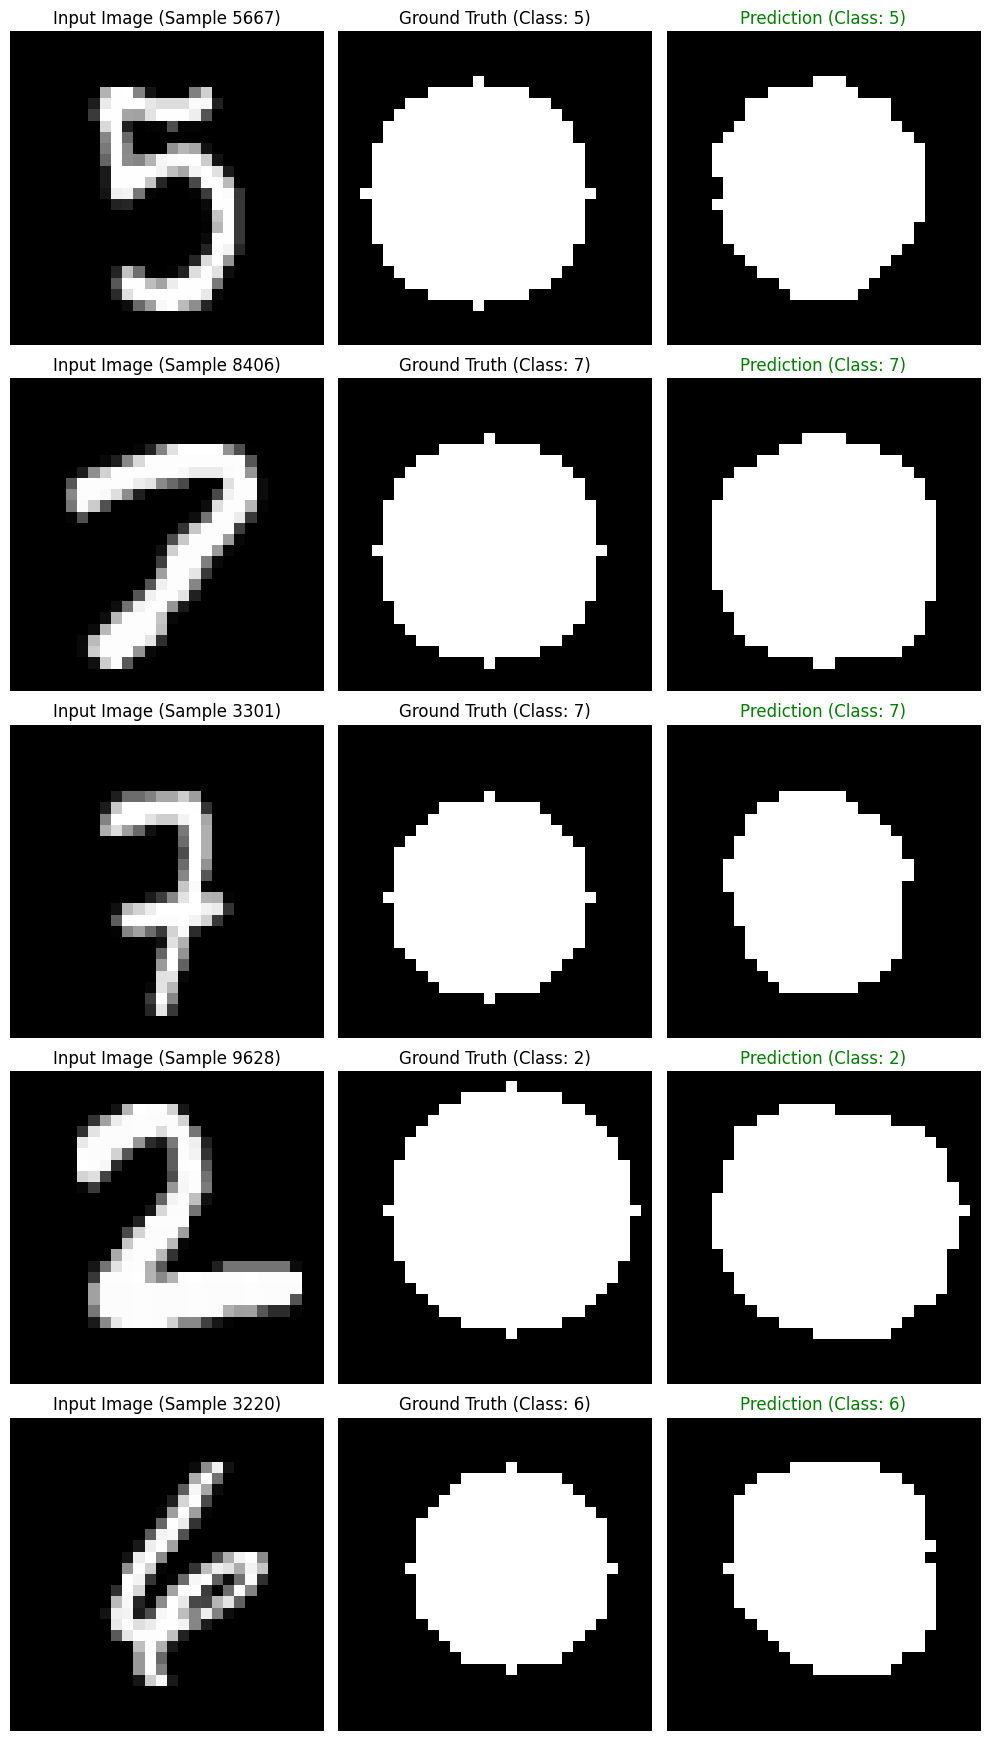

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Get Model Predictions ---
# This model returns a list: [class_probabilities, mask_probabilities]
print("Running model.predict() on the test set...")
predictions = model.predict(x_test)
pred_class_probs = predictions[0]
pred_masks_prob = predictions[1]

# --- 2. Process Predictions ---
# Get the single predicted class index (0-9)
pred_labels = np.argmax(pred_class_probs, axis=1)

# Convert predicted mask probabilities to binary masks (0 or 1)
pred_masks_binary = np.round(pred_masks_prob)

# --- 3. Select 5 Random Samples ---
num_to_show = 5
indices = np.random.choice(len(x_test), num_to_show, replace=False)

# --- 4. Plot the Results ---
print(f"Plotting {num_to_show} random test samples...")
fig, axes = plt.subplots(num_to_show, 3, figsize=(10, num_to_show * 3.5))

for i, idx in enumerate(indices):
    img = np.squeeze(x_test[idx])
    true_mask = np.squeeze(y_test_mask[idx])
    true_label = y_test_class[idx]

    pred_mask = np.squeeze(pred_masks_binary[idx])
    pred_label = pred_labels[idx]

    # --- Plot Input Image ---
    axes[i, 0].imshow(img, cmap='gray')
    axes[i, 0].set_title(f"Input Image (Sample {idx})")
    axes[i, 0].axis('off')

    # --- Plot Ground Truth ---
    axes[i, 1].imshow(true_mask, cmap='gray')
    axes[i, 1].set_title(f"Ground Truth (Class: {true_label})")
    axes[i, 1].axis('off')

    # --- Plot Predicted Mask ---
    # Add a colored title (green=correct, red=incorrect)
    color = "green" if true_label == pred_label else "red"
    axes[i, 2].imshow(pred_mask, cmap='gray')
    axes[i, 2].set_title(f"Prediction (Class: {pred_label})", color=color)
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()